# Chicago Crime and SocioEconomic Data

The data comes from the Chicago data portal. The crime data from [this](https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data) page, while the socioeconomic data from [this](https://data.cityofchicago.org/Health-Human-Services/Selected-socioeconomic-indicators-by-neighborhood/i9hv-en6g/about_data) page.



## The Data

The crime data is composed of the following columns:
'ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location'

Before starting this notebook I opened the crime file in VIM and removed the spaces from the column headings made up of more than one word to make working with the data easier. The columns of a lazy data frame are read only so this seemed the easiest way to make the change. For the census data I made the modifications in the code below.

For the crimes dataset I use the *scan_csv* over the *read_csv* method to create a lazy dataframe as the file is 2.3GB in size and I don't think my laptop would appreciate opening this normally.

For the census data I use *read_csv* as it's a small file, and I attatch the census data only once having processed the crime data from its raw state into summarised data frames.

In [48]:
# Import the libraries
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import statsmodels.api as sm

# Load the two dataframes.
crime_df = pl.scan_csv(
    'data/chicago-crime/Crimes_-_2001_to_Present_20260822.csv', 
    try_parse_dates=True)

census_df = pl.read_csv(
    'data/chicago-crime/Census_Data_-_Selected_socioeconomic_indicators_in_Chicago,_2008_–_2012_20260822.csv'
)

# Alter the census data column headings for ease of use and standardise column for joining with crime data (CommunityArea)
census_df.columns = [
    'CommunityArea',
    'CommunityAreaName',
    'PercentHousingCrowded',
    'PercentHouseholdsBelowPovery',
    'PercentAged16AboveUnemployed',
    'PercentAged25AboveWithoutHighSchoolDiploma',
    'PercentAgedUnder18OrOver64',
    'PerCapitaIncome',
    'HardshipIndex']

    

A note on both dataframes. Their connection is the numeric value 'CommunityArea', which is called the same in both dataframes after the above changes. Both tables have rows where the value is empty/Null. The rows with the empty value for 'CommunityArea' stands for the area of the whole of Chicago.

In the cell below I update the null values to -1 so that the joins used later works correctly. Existing values are all positive, so this makes it easy to find the modified values in case they need filtering.

Finally, in the crime dataframe there is an entry for the 'CommunityArea' of 0. There are only 76 crimes recorded under this value, so a very small amount in the scheme of things. While there is no corresponding 'CommunityArea' in the census data, there is location data for the crimes including the Block they were commited on, of which there are only five distinct entries.
I use a left join when connecting the crime data to the census data so that we include that data even though we have no corresponding census data.

In [49]:
# Update the null values in both tables to allow joining later on

crime_df = crime_df.with_columns(
    pl.col("CommunityArea").fill_null(-1),
)

census_df = census_df.with_columns(
    pl.col("CommunityArea").fill_null(-1)
)

In [50]:
# Create a summary calculating the number of crimes for every distinct crime type

count_by_type_df = crime_df.sql("""
    SELECT PrimaryType, COUNT(ID) AS NumberOfCrimes
    FROM self
    GROUP BY PrimaryType
""").collect().sort("NumberOfCrimes", descending=True)

# Create a summary calculating the number of crimes for every distinct community area
count_by_area_df = crime_df.sql("""
   SELECT DISTINCT CommunityArea, COUNT(ID) AS NumberOfCrimes
   FROM self
   GROUP BY CommunityArea
""").collect().sort("NumberOfCrimes", descending=True)

# Create a summary calculating the number of crimes for every distinct combination of crime type and community area
count_by_type_and_area_df = crime_df.sql("""
    SELECT PrimaryType, CommunityArea, COUNT(ID) AS NumberOfCrimes
    FROM self
    GROUP BY PrimaryType, CommunityArea
""").collect().sort("NumberOfCrimes", descending=True)

# Add the census data to the community summary to access the textual representation of the community
enriched_count_by_area_df = count_by_area_df.join(census_df, on="CommunityArea", how="left")
enriched_count_by_area_and_type_df = count_by_type_and_area_df.join(census_df, on="CommunityArea", how="left")

# Looking at the Data

In the plot below we can see there is a range of crimes in different income areas. Three stand out starkly, two for their total number of crimes, and a third for being in the highest category of income while also being the third highest in the dataset. We will look at these in particular. 

Text(0, 0.5, 'Number of Crimes')

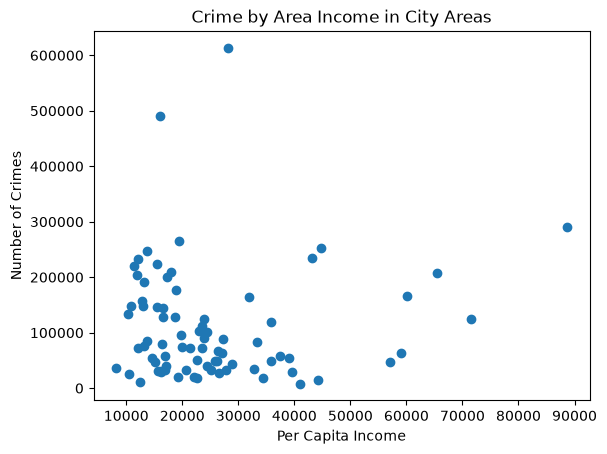

In [51]:
fig, ax = plt.subplots()
ax.scatter(enriched_count_by_area_df['PerCapitaIncome'], 
            enriched_count_by_area_df['NumberOfCrimes'])
            
ax.set_title("Crime by Area Income in City Areas")
ax.set_xlabel("Per Capita Income")
ax.set_ylabel("Number of Crimes")

As we can see below the largest outlier is the catch all area of Chicago, this was expected. The second highest is a surprise as it has around 200,000 more crimes reported than the next highest area.

In [52]:
outliers = enriched_count_by_area_df.filter(pl.col("NumberOfCrimes") > 270000)
print(outliers)

shape: (3, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Community ┆ NumberOfC ┆ Community ┆ PercentHo ┆ … ┆ PercentAg ┆ PercentAg ┆ PerCapita ┆ Hardship │
│ Area      ┆ rimes     ┆ AreaName  ┆ usingCrow ┆   ┆ ed25Above ┆ edUnder18 ┆ Income    ┆ Index    │
│ ---       ┆ ---       ┆ ---       ┆ ded       ┆   ┆ WithoutHi ┆ OrOver64  ┆ ---       ┆ ---      │
│ i64       ┆ u32       ┆ str       ┆ ---       ┆   ┆ ghS…      ┆ ---       ┆ i64       ┆ i64      │
│           ┆           ┆           ┆ f64       ┆   ┆ ---       ┆ f64       ┆           ┆          │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ -1        ┆ 613723    ┆ CHICAGO   ┆ 4.7       ┆ … ┆ 19.5      ┆ 33.5      ┆ 28202     ┆ null     │
│ 25        ┆ 489779    ┆ Austin    ┆ 6.3       ┆ … ┆ 24.4      ┆ 37.9      

Austin has the greatest amount of crimes by area outwith the city-wide category. Also interesting is the large number of crimes in the highest income area of Near North Side. Lets look at the top ten crimes for each of these areas.

In Austin the two highest values are Battery and Narcotics, with a gradual decline down the crime types as the number recorded decreases.

In Near North Side Theft is the highest value by far, around 80,000 instances more than the second position.

In [53]:
austin_df = enriched_count_by_area_and_type_df.filter(pl.col("CommunityArea") == 25)
austin_df.head(10)

PrimaryType,CommunityArea,NumberOfCrimes,CommunityAreaName,PercentHousingCrowded,PercentHouseholdsBelowPovery,PercentAged16AboveUnemployed,PercentAged25AboveWithoutHighSchoolDiploma,PercentAgedUnder18OrOver64,PerCapitaIncome,HardshipIndex
str,i64,u32,str,f64,f64,f64,f64,f64,i64,i64
"""BATTERY""",25,99523,"""Austin""",6.3,28.6,22.6,24.4,37.9,15957,73
"""NARCOTICS""",25,95624,"""Austin""",6.3,28.6,22.6,24.4,37.9,15957,73
"""THEFT""",25,65379,"""Austin""",6.3,28.6,22.6,24.4,37.9,15957,73
"""CRIMINAL DAMAGE""",25,45286,"""Austin""",6.3,28.6,22.6,24.4,37.9,15957,73
"""ASSAULT""",25,32991,"""Austin""",6.3,28.6,22.6,24.4,37.9,15957,73
"""OTHER OFFENSE""",25,30164,"""Austin""",6.3,28.6,22.6,24.4,37.9,15957,73
"""MOTOR VEHICLE THEFT""",25,21992,"""Austin""",6.3,28.6,22.6,24.4,37.9,15957,73
"""ROBBERY""",25,20967,"""Austin""",6.3,28.6,22.6,24.4,37.9,15957,73
"""BURGLARY""",25,18238,"""Austin""",6.3,28.6,22.6,24.4,37.9,15957,73


In [54]:
near_north_df = enriched_count_by_area_and_type_df.filter(pl.col("CommunityArea") == 8)
near_north_df.head(10)

PrimaryType,CommunityArea,NumberOfCrimes,CommunityAreaName,PercentHousingCrowded,PercentHouseholdsBelowPovery,PercentAged16AboveUnemployed,PercentAged25AboveWithoutHighSchoolDiploma,PercentAgedUnder18OrOver64,PerCapitaIncome,HardshipIndex
str,i64,u32,str,f64,f64,f64,f64,f64,i64,i64
"""THEFT""",8,119125,"""Near North Side""",1.9,12.9,7.0,2.5,22.6,88669,1
"""BATTERY""",8,38015,"""Near North Side""",1.9,12.9,7.0,2.5,22.6,88669,1
"""DECEPTIVE PRACTICE""",8,30022,"""Near North Side""",1.9,12.9,7.0,2.5,22.6,88669,1
"""CRIMINAL DAMAGE""",8,18316,"""Near North Side""",1.9,12.9,7.0,2.5,22.6,88669,1
"""CRIMINAL TRESPASS""",8,15062,"""Near North Side""",1.9,12.9,7.0,2.5,22.6,88669,1
"""ASSAULT""",8,12196,"""Near North Side""",1.9,12.9,7.0,2.5,22.6,88669,1
"""NARCOTICS""",8,10968,"""Near North Side""",1.9,12.9,7.0,2.5,22.6,88669,1
"""OTHER OFFENSE""",8,10304,"""Near North Side""",1.9,12.9,7.0,2.5,22.6,88669,1
"""MOTOR VEHICLE THEFT""",8,7980,"""Near North Side""",1.9,12.9,7.0,2.5,22.6,88669,1


In the plot below we look at the number of occurrences of Theft in total for each level of Per Capita Income. As shown by the linear regression comparing thefts as a function of income, there is a positive correlation.

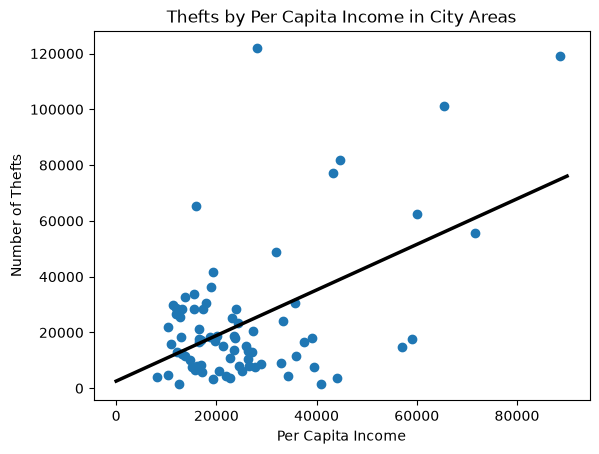

In [55]:

# Here we filter out the Community Area zero value as this has no census data and causes the linear regression to fail
theft_df = enriched_count_by_area_and_type_df.filter(
    (pl.col("PrimaryType") == "THEFT") & (pl.col("CommunityArea") != 0)
)

fig, ax = plt.subplots()
ax.scatter(theft_df['PerCapitaIncome'], 
            theft_df['NumberOfCrimes'])
ax.set_title("Thefts by Per Capita Income in City Areas")
ax.set_xlabel("Per Capita Income")
ax.set_ylabel("Number of Thefts")

slope, intercept = np.polyfit(theft_df['PerCapitaIncome'],
                                                theft_df['NumberOfCrimes'],
                                                deg=1)
xseq = np.linspace(0, 90000, 10)
ax.plot(xseq, intercept + slope * xseq, color="k", lw=2.5)


Now lets look at theft in the Near North Side, over two years, plotted first by timeseries based on date, and then categorical on time buckets.

Text(0, 0.5, 'Number of Thefts')

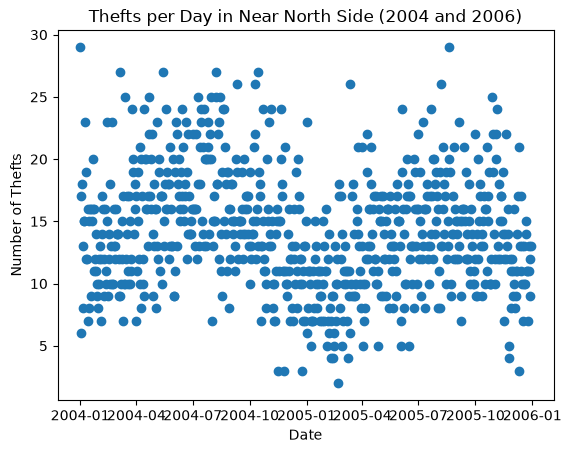

In [56]:
# Filter the crime dataframe for the Near North Side area, and for the crime of Theft
near_north_theft_df = crime_df.filter(pl.col("CommunityArea") == 8).filter(pl.col("PrimaryType") == "THEFT").collect()
# Add a DateTime column parsed from the string Date field
near_north_theft_df = near_north_theft_df.with_columns(
    (pl.col("Date").str.to_datetime("%m/%d/%Y %I:%M:%S %p")).alias("dt"))

# Create the date, hour, and day of year bucket fields for use as the x axis field
near_north_theft_df = near_north_theft_df.with_columns(    
    (pl.col("dt").dt.date().alias("bucket_date")),
    (pl.col(name="dt").dt.hour().alias("bucket_hour")),
    (pl.col("dt").dt.ordinal_day().alias("doy")),
    (pl.col(name="dt").dt.year().alias("bucket_year"))
    )

# Create the aggregate count by date filtered for two years taken at random
near_north_theft_date_df = near_north_theft_df.filter(
        pl.col("dt").is_between(datetime(2004,1,1), datetime(2005,12,31))
    ).group_by(["bucket_date"]).len(name="NumberOfCrimes")  

fig, ax = plt.subplots()
ax.scatter(near_north_theft_date_df['bucket_date'], 
            near_north_theft_date_df['NumberOfCrimes'])
ax.set_title("Thefts per Day in Near North Side (2004 and 2006)")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Thefts")

In the plot above there looks to be a little bit of seasonality to the data. Lets look at a number of years together and see if the seasonality is common across a larger subset of years.

So create a doy value for the x axis to be able to fit a loess or spline to it, groupby doy, year, year as a categorical value to facet the plots, lets try four months for a nice square output

https://www.statsmodels.org/devel/generated/statsmodels.nonparametric.smoothers_lowess.lowess.html




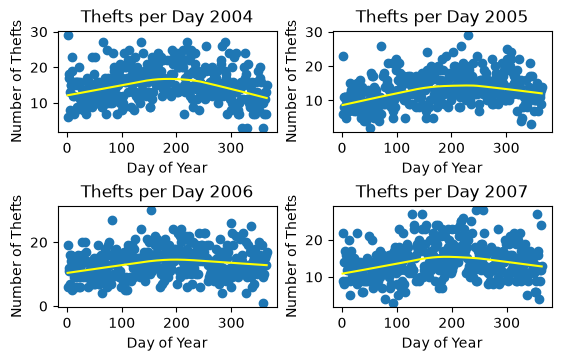

In [57]:
# Create the aggregate count by day of year and year
near_north_theft_doy_df = near_north_theft_df.filter(
        pl.col("dt").is_between(datetime(2004,1,1), datetime(2007,12,31))
    ).group_by(["bucket_year", "doy"]).len(name="NumberOfCrimes") 

fig, axs = plt.subplots(ncols=2, nrows=2, layout="constrained",
                        figsize=(5.5, 3.5))


for year in [2004, 2005, 2006, 2007]:
    if year == 2004:
        data = near_north_theft_doy_df.filter(pl.col("bucket_year") == 2004)
        row = 0
        col = 0
        lowess = sm.nonparametric.lowess
        x = data['doy']
        y = data['NumberOfCrimes']
        z = lowess(y, x, return_sorted=True)
    if year == 2005:
        data = near_north_theft_doy_df.filter(pl.col("bucket_year") == 2005)
        row = 0
        col = 1
        lowess = sm.nonparametric.lowess
        x = data['doy']
        y = data['NumberOfCrimes']
        z = lowess(y, x, return_sorted=True)
    if year == 2006:
        data = near_north_theft_doy_df.filter(pl.col("bucket_year") == 2006)
        row = 1
        col = 0
        lowess = sm.nonparametric.lowess
        x = data['doy']
        y = data['NumberOfCrimes']
        z = lowess(y, x, return_sorted=True)
    if year == 2007:
        data = near_north_theft_doy_df.filter(pl.col("bucket_year") == 2007)
        row = 1
        col = 1
        lowess = sm.nonparametric.lowess
        x = data['doy']
        y = data['NumberOfCrimes']
        z = lowess(y, x, return_sorted=True)

    axs[row, col].scatter(x=data['doy'], y=data['NumberOfCrimes'])
    axs[row, col].set_title(f"Thefts per Day {year}")
    axs[row, col].set_xlabel("Day of Year")
    axs[row, col].set_ylabel("Number of Thefts")
    axs[row, col].plot(z[:, 0], z[:, 1],color="yellow")
    






In the chart below, we can see the number of Thefts that occur in each 24 hour bracket, over the years 2004 to 2006 in Near North Side. There is a strong signal for the trend of when crimes are committed.

Text(0, 0.5, 'Number of Thefts')

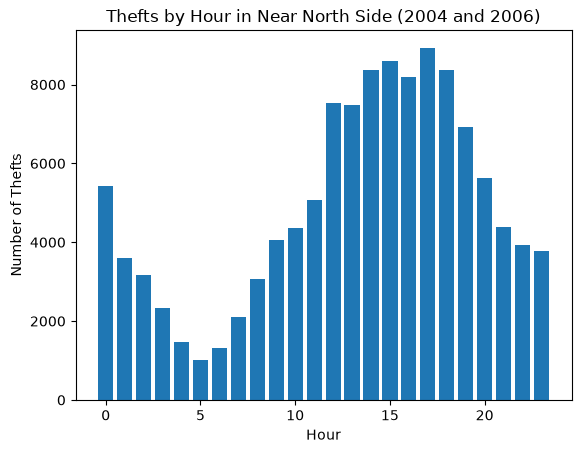

In [58]:
# Aggregate the number of crimes committed per hour
near_north_theft_hour_df = near_north_theft_df.group_by("bucket_hour").len(name="NumberOfCrimes")  

fig, ax = plt.subplots()
ax.bar(near_north_theft_hour_df["bucket_hour"], near_north_theft_hour_df["NumberOfCrimes"])
ax.set_title("Thefts by Hour in Near North Side (2004 and 2006)")
ax.set_xlabel("Hour")
ax.set_ylabel("Number of Thefts")

Geo Data Map and columns of different types of theft in near north side

https://geopandas.org/en/latest/docs/user_guide/mapping.html

https://geopandas.org/en/latest/docs/user_guide/data_structures.html

https://geopandas.org/en/latest/docs/user_guide/mergingdata.html

In [ ]:
# The highest crime per area



SQLInterfaceError: no table or struct column named 'a' found

In [68]:
r = enriched_count_by_area_and_type_df.with_columns(
    pl.col("NumberOfCrimes").rank(method="min", descending=True).over("CommunityAreaName").alias("rnk")
).filter(
    pl.col("rnk") == 1
).drop("rnk")

In [69]:
print(r)

shape: (79, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ PrimaryTy ┆ Community ┆ NumberOfC ┆ Community ┆ … ┆ PercentAg ┆ PercentAg ┆ PerCapita ┆ Hardship │
│ pe        ┆ Area      ┆ rimes     ┆ AreaName  ┆   ┆ ed25Above ┆ edUnder18 ┆ Income    ┆ Index    │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ WithoutHi ┆ OrOver64  ┆ ---       ┆ ---      │
│ str       ┆ i64       ┆ u32       ┆ str       ┆   ┆ ghS…      ┆ ---       ┆ i64       ┆ i64      │
│           ┆           ┆           ┆           ┆   ┆ ---       ┆ f64       ┆           ┆          │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ THEFT     ┆ -1        ┆ 122094    ┆ CHICAGO   ┆ … ┆ 19.5      ┆ 33.5      ┆ 28202     ┆ null     │
│ THEFT     ┆ 8         ┆ 119125    ┆ Near      ┆ … ┆ 2.5       ┆ 22.6     

In [70]:
x = enriched_count_by_area_and_type_df.sort("NumberOfCrimes", descending=True).unique(subset="CommunityAreaName", keep="first")

In [71]:
print(x)


shape: (79, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ PrimaryTy ┆ Community ┆ NumberOfC ┆ Community ┆ … ┆ PercentAg ┆ PercentAg ┆ PerCapita ┆ Hardship │
│ pe        ┆ Area      ┆ rimes     ┆ AreaName  ┆   ┆ ed25Above ┆ edUnder18 ┆ Income    ┆ Index    │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ WithoutHi ┆ OrOver64  ┆ ---       ┆ ---      │
│ str       ┆ i64       ┆ u32       ┆ str       ┆   ┆ ghS…      ┆ ---       ┆ i64       ┆ i64      │
│           ┆           ┆           ┆           ┆   ┆ ---       ┆ f64       ┆           ┆          │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ BATTERY   ┆ 43        ┆ 58076     ┆ South     ┆ … ┆ 14.0      ┆ 35.7      ┆ 19398     ┆ 55       │
│           ┆           ┆           ┆ Shore     ┆   ┆           ┆          